In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import sqrt,erfc,exp

from scipy.optimize import curve_fit


In [2]:
data_Q = pd.read_excel(r'C:\Users\Nicolas Onillon\Documents\UNINe\géologie\dispersion.xlsx','debit')
data_conductivite = pd.read_excel(r'C:\Users\Nicolas Onillon\Documents\UNINe\géologie\dispersion.xlsx','conductivite')
Q = data_Q['Q_[m3/s]']
Q_err = data_Q['err_Q']
t0 = [38,40,39]
t_err = [1,1,1]
t = data_conductivite['temps_[s]']
C = data_conductivite['C_[microS/s]']
#erreur C
C_err = []
for k in C:
    if k < (2000-385):
        C_err.append(2)
    else: C_err.append(20)

In [3]:
def moyenne_ponderee(x,sigma):
    w = []
    for i in range(len(sigma)):
        w.append(1/sigma[i]**2)

    # Calcul des xiwi
    wx = []
    for i in range(len(x)):
        wx.append(x[i]*w[i])

    # Calcul de la moyenne ponderee
    mean = sum(wx)/sum(w)

    # Calcul de l'ecart à la moyenne de xi
    ecart_moy = []
    for i in range(len(x)):
        ecart_moy.append(w[i]*(x[i]-mean)**2)

    # Calcul sigma
    sigma_x = np.sqrt(sum(ecart_moy)/sum(w))

    return mean, 2*sigma_x

In [4]:
# Calcul de alpha moyen et de son erreur
mean_Q, sigma_Q = moyenne_ponderee(Q, Q_err)
print(f'Q = {mean_Q} +/- {sigma_Q} m3/s')

mean_t, sigma_t = moyenne_ponderee(t0, t_err)
print(f't = {mean_t} +/- {sigma_t} sec')

Q = 2.9921593052612783e-06 +/- 1.1094466429484863e-08 m3/s
t = 39.0 +/- 1.632993161855452 sec


C:\Users\Nicolas Onillon\AppData\Local\Temp\ipykernel_21628\868942569.py:15: RuntimeWarning: divide by zero encountered in scalar divide
  er1 = (l-adv*ti)/(2*np.sqrt(D*ti))
C:\Users\Nicolas Onillon\AppData\Local\Temp\ipykernel_21628\868942569.py:16: RuntimeWarning: divide by zero encountered in scalar divide
  er2 = (l+adv*ti)/(2*np.sqrt(D*ti))
C:\Users\Nicolas Onillon\AppData\Local\Temp\ipykernel_21628\868942569.py:15: RuntimeWarning: invalid value encountered in sqrt
  er1 = (l-adv*ti)/(2*np.sqrt(D*ti))
C:\Users\Nicolas Onillon\AppData\Local\Temp\ipykernel_21628\868942569.py:16: RuntimeWarning: invalid value encountered in sqrt
  er2 = (l+adv*ti)/(2*np.sqrt(D*ti))


porosité: 0.4447101683889259 +/- 0.00034113448856659077
dispersion: 2.8377457055508976e-06 +/- 3.929277920944059e-07


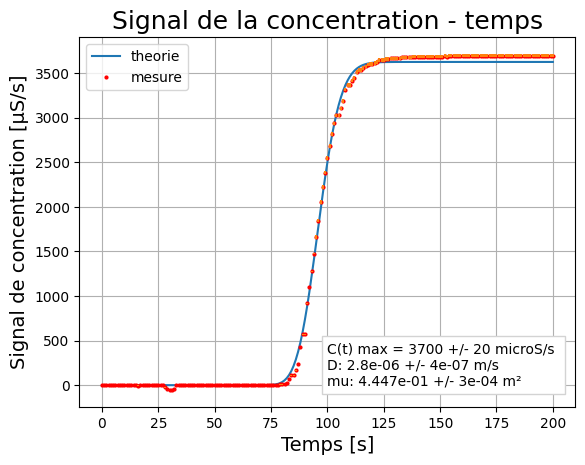

In [10]:
'''parametres fixes'''
A, A_err = 22*10**(-4), 3*10**(-4)  # m2
l, l_err = 0.295, 0.04    # m
C0, C0_err = 3625, 11    # microS/s
q = mean_Q/A           # m/s
q_err = q*sqrt((sigma_Q/mean_Q)**2+(A_err/A)**2)
d0 = 1.3*10**(-9)  # m2/s

def function_for_fit(t, mu, alpha):
    y = []
    adv = q/mu
    D = alpha*adv+d0
    ex = adv*l/D
    for ti in t:
        er1 = (l-adv*ti)/(2*np.sqrt(D*ti))
        er2 = (l+adv*ti)/(2*np.sqrt(D*ti))
        y.append(C0/2*(erfc(er1)+np.exp(ex)*erfc(er2)))
    return y

'''valeurs'''
param_opt, param_cov = curve_fit(function_for_fit,t,C)
mu_opt, alpha_opt = param_opt
mu_cov, alpha_cov = param_cov
mu_cov, alpha_cov = mu_cov[0], alpha_cov[0]
mu_err, alpha_err = np.sqrt(mu_cov).squeeze(), np.sqrt(alpha_cov).squeeze()
adv_opt = q/mu_opt
adv_err = adv_opt*sqrt((q_err/q)**2+(mu_err/mu_opt)**2)
D = alpha_opt*adv_opt+d0
D_err = D*sqrt((alpha_err/alpha_opt)**2+(adv_err/adv_opt)**2)
C_opt = function_for_fit(t,mu_opt,alpha_opt)
print(f"porosité: {mu_opt} +/- {mu_err}")
print(f"dispersion: {D} +/- {D_err}")

'''graphe'''
fig, cond = plt.subplots()
cond.plot(t,C_opt,label = 'theorie')
cond.plot(t,C,marker='o',color='r', linestyle='none',markersize=2,label = 'mesure')
cond.errorbar(t,C,yerr=C_err,linestyle='none')
cond.set_xlabel('Temps [s]',fontsize=14)
cond.set_ylabel('Signal de concentration [\u00B5S/s]',fontsize=14)
cond.set_title('Signal de la concentration - temps',fontsize=18)
cond.grid()
cond.text (100,0, f"C(t) max = 3700 +/- 20 microS/s \nD: {D:.1e} +/- {D_err:.0e} m/s \nmu: {mu_opt:.3e} +/- {mu_err:.0e} m\u00B2",bbox=dict(facecolor='white',edgecolor='lightgrey'))
plt.legend()

#plt.savefig(f'C:/Users/Nicolas Onillon/Documents/UNINe/géologie/concentration.pdf')

In [ ]:
'''vitesse advection'''
# selon porosité
mu_t, mu_t_err = 0.422, 0.006
mu_ta, mu_ta_err = 0.463, 0.005
adv_t = q/mu_t # m/s
adv_ta = q/mu_ta
adv_t_err = adv_t*sqrt((q_err/q)**2+(mu_t_err/mu_t)**2)
adv_ta_err = adv_ta*sqrt((q_err/q)**2+(mu_ta_err/mu_ta)**2)
print(f"vitesse moyenne d'advection théorique: {adv_t} +/- {adv_t_err} m/s")
print(f"vitesse moyenne d'advection non tassé théorique: {adv_ta} +/- {adv_ta_err} m/s")

#selon dispersion
ti = 96
ti_err = 1
adv_m = l/96
adv_m_err = adv_m*sqrt((l_err/l)**2+(ti_err/ti)**2)
print(f"vitesse moyenne d'advection manuelle: {adv_m} +/- {adv_m_err} m/s")

In [ ]:
'''varier mu'''
C1 = function_for_fit(t,0.3,alpha_opt)
C2 = function_for_fit(t,0.6,alpha_opt)

'''graphe'''
fig, cond = plt.subplots()
cond.plot(t,C1,label = 'mu = 0.3')
cond.plot(t,C2,label = 'mu = 0.6')
cond.plot(t,C,marker='o',color='r', linestyle='none',markersize=2,label = 'mesure')
cond.set_xlabel('Temps [s]',fontsize=14)
cond.set_ylabel('Signal de concentration [\u00B5S/s]',fontsize=14)
cond.set_title('Signal de la concentration - temps',fontsize=18)
cond.grid()
plt.legend()

#plt.savefig(f'C:/Users/Nicolas Onillon/Documents/UNINe/géologie/variation_mu.pdf')

In [ ]:
'''varier mu'''
C1 = function_for_fit(t,mu_opt,0.00045)
C2 = function_for_fit(t,mu_opt,0.04)

D1 = 0.00045*adv_opt+d0
D2 = 0.01*adv_opt+d0
print(f"D1: {D1}\nD2: {D2}")
'''graphe'''
fig, cond = plt.subplots()
cond.plot(t,C1,label = f'D = {D1:.3e} m/s')
cond.plot(t,C2,label = f'D = {D2:.3e} m/s')
cond.plot(t,C,marker='o',color='r', linestyle='none',markersize=2,label = 'mesure')
cond.set_xlabel('Temps [s]',fontsize=14)
cond.set_ylabel('Signal de concentration [\u00B5S/s]',fontsize=14)
cond.set_title('Signal de la concentration - temps',fontsize=18)
cond.grid()
plt.legend()

#plt.savefig(f'C:/Users/Nicolas Onillon/Documents/UNINe/géologie/variation_D.pdf')